# 01 · Data sources and the regional daily series

**Goal.** Start from the analysis-ready Zarr stores, understand what is in them, and reduce a
gridded precipitation record to the single daily time series that the day-selection step in
notebook 02 will rank.

This notebook is the foundation of the chain:

```
01 stores → regional series   →  02 ENSO phase + day selection
                                 →  03 ERA5 850 hPa wind for those days
                                    →  04 SOM construction + node composites
                                    →  05 integrated vapor transport per node
```

## The stores

All four Zarr stores were built by subsetting global products to a NW South America (NWSA)
window, `lat [-20, 15]`, `lon [-95, -60]`, and appending along time. They live on a group
filesystem (paths in `config.py`); nothing here depends on how they were built, only on their
structure.

| Store | Product | Resolution | Period | Variables |
|---|---|---|---|---|
| `chirps-nwsa.zarr` | CHIRPS v2.0 daily | 0.05°, 700×700 | 1981-01-01 → present | `precip` (mm/day) |
| `imerg-nwsa.zarr` | GPM IMERG Final Daily V07 | 0.1°, 350×350 | 2000-06-01 → 2025-09-30 | `precipitation`, `precipitation_cnt` |
| `era5-monthly-pl-nwsa.zarr` | ERA5 monthly, pressure levels | 0.25° | 1979-01 → 2026-08 | `U`, `V`, `T`, `Z`, `Q` |
| `esacci-sm-nwsa.zarr` | ESA CCI Soil Moisture COMBINED | 0.25°, 140×140 | 1978-11-01 → 2024-12-31 | `sm`, `sm_uncertainty`, `flag` |

Daily 850 hPa wind is **not** in any of these — the ERA5 store is monthly means only. Notebook 03
pulls daily wind from the public ARCO-ERA5 archive instead.

> **Gotcha that costs a debugging cycle.** These stores do *not* share a coordinate naming
> convention. CHIRPS and ERA5 use `latitude`/`longitude`; IMERG uses `lat`/`lon`. Any function
> meant to work across both must detect the names rather than assume them — `coord_names()`
> below does this.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")
from config import CHIRPS_ZARR, IMERG_ZARR, PROVINCES_GPKG, DATA_DIR

pd.set_option("display.width", 120)

## 1. Open a store and look at it

Zarr stores open lazily: `open_zarr` reads only metadata, so this is instant even for a
multi-gigabyte store. Nothing is read from disk until you call `.load()`, `.values`, or an
aggregation.

In [2]:
chirps = xr.open_zarr(CHIRPS_ZARR)
print(chirps)
print()
print("chunks:", {k: v for k, v in chirps.chunks.items()})

<xarray.Dataset> Size: 33GB
Dimensions:    (time: 16648, latitude: 700, longitude: 700)
Coordinates:
  * time       (time) datetime64[ns] 133kB 1981-01-01 1981-01-02 ... 2026-07-31
  * latitude   (latitude) float32 3kB -19.98 -19.93 -19.88 ... 14.88 14.92 14.97
  * longitude  (longitude) float32 3kB -94.98 -94.93 -94.88 ... -60.08 -60.03
Data variables:
    precip     (time, latitude, longitude) float32 33GB dask.array<chunksize=(366, 100, 100), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2026-08-14
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day....
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_u

The chunking matters for everything downstream. A store chunked `(time=366, lat=100, lon=100)`
is cheap to read as *whole spatial fields for a contiguous run of days* and expensive to read as
*a single grid cell across all time* — the latter touches every chunk in the store. Our access
pattern in this notebook is the expensive one (a long time series at fixed location), which is
why we do it once here and cache the result to CSV rather than re-reading the store in later
notebooks.

In [3]:
# helper: stores disagree on coordinate names -- detect rather than assume
def coord_names(ds):
    lat = "latitude" if "latitude" in ds.coords else "lat"
    lon = "longitude" if "longitude" in ds.coords else "lon"
    return lat, lon

for label, ds in [("CHIRPS", chirps), ("IMERG", xr.open_zarr(IMERG_ZARR))]:
    lat, lon = coord_names(ds)
    print(f"{label:8s} coords -> {lat}/{lon};  "
          f"lat ascending: {bool(ds[lat].values[0] < ds[lat].values[-1])}")

CHIRPS   coords -> latitude/longitude;  lat ascending: True
IMERG    coords -> lat/lon;  lat ascending: True


> **Second gotcha, same family.** Note the latitude *ordering* differs too. `ds.sel(lat=slice(a, b))`
> on an xarray object requires `a`, `b` in the same order as the stored coordinate — slicing
> descending on an ascending axis silently returns an **empty** array rather than raising. Always
> check the direction, or use `sorted()` on the bounds:
>
> ```python
> lo, hi = sorted([lat_min, lat_max])
> sub = ds.sel(**{lat: slice(lo, hi)})   # safe only if the axis ascends
> ```

## 2. Build the province mask

We want a single daily number representing precipitation *over Guayas province*. That needs a
mask: which grid cells fall inside the province polygon.

We test cell **centers** against the polygon. This is the simplest correct choice for
0.05° cells over a province several degrees across; a fractional-area weighting would matter
for a much smaller region or much coarser grid.

In [4]:
prov = gpd.read_file(PROVINCES_GPKG)
name_col = [c for c in prov.columns
            if prov[c].astype(str).str.contains("Guayas", case=False, na=False).any()][0]
guayas = prov[prov[name_col].astype(str).str.contains("Guayas", case=False)]
guayas_geom = guayas.union_all() if hasattr(guayas, "union_all") else guayas.unary_union

print("province name column:", name_col)
print("geometry bounds (lon_min, lat_min, lon_max, lat_max):",
      tuple(round(v, 3) for v in guayas_geom.bounds))

province name column: name
geometry bounds (lon_min, lat_min, lon_max, lat_max): (-80.543, -3.065, -79.127, -0.837)


In [5]:
from shapely.geometry import Point
from shapely.prepared import prep

def province_mask(ds, geom, pad=0.5):
    """Boolean (lat, lon) mask of cells whose CENTER falls inside `geom`.

    The bounding-box pre-filter is not cosmetic: testing every cell in a 700x700 NWSA grid
    against the polygon is ~500k point-in-polygon tests, most of them obviously outside.
    """
    lat_name, lon_name = coord_names(ds)
    lat, lon = ds[lat_name].values, ds[lon_name].values
    lon_min, lat_min, lon_max, lat_max = geom.bounds
    lat_sel = (lat >= lat_min - pad) & (lat <= lat_max + pad)
    lon_sel = (lon >= lon_min - pad) & (lon <= lon_max + pad)

    pg = prep(geom)
    LON, LAT = np.meshgrid(lon, lat)
    mask = np.zeros(LAT.shape, dtype=bool)
    ii, jj = np.where(np.outer(lat_sel, lon_sel))
    for i, j in zip(ii, jj):
        if pg.contains(Point(LON[i, j], LAT[i, j])):
            mask[i, j] = True
    return mask

mask_chirps = province_mask(chirps, guayas_geom)
print("Guayas CHIRPS cells (0.05 deg):", int(mask_chirps.sum()))

Guayas CHIRPS cells (0.05 deg): 489


## 3. Reduce to a daily series — two different metrics

Two reductions answer genuinely different questions, and notebook 02 will show they disagree:

- **Province area-weighted mean** — "how wet was Guayas as a whole today?" Sensitive to
  widespread, organized rainfall. This is the metric to rank if you care about province-scale
  flooding.
- **Spatial maximum** — "how intense was the wettest point in Guayas today?" Sensitive to
  localized convective bursts that may cover only a few cells.

The area weighting is `cos(latitude)`, because a 0.05° × 0.05° cell shrinks in true area as you
move away from the equator. Over Guayas (≈2°S) the correction is small (~0.1%), but the habit
generalizes to domains where it is not.

In [6]:
def regional_series(ds, var, mask, chunk_days=400):
    """Area-weighted mean and spatial max of `var` over `mask`, for every timestep.

    Processed in time blocks so that peak memory stays bounded regardless of record length.
    """
    lat_name, lon_name = coord_names(ds)
    lat = ds[lat_name].values
    _, LAT = np.meshgrid(ds[lon_name].values, lat)
    w = np.where(mask, np.cos(np.deg2rad(LAT)), 0.0)
    wsum = w.sum()

    da = ds[var]
    n = da.sizes["time"]
    out_mean = np.empty(n)
    out_max = np.empty(n)
    for i0 in range(0, n, chunk_days):
        i1 = min(i0 + chunk_days, n)
        block = da.isel(time=slice(i0, i1)).values          # (t, lat, lon)
        out_mean[i0:i1] = np.nansum(block * w[None], axis=(1, 2)) / wsum
        blk = np.where(mask[None], block, np.nan)
        out_max[i0:i1] = np.nanmax(blk, axis=(1, 2))
    return pd.DataFrame({"date": pd.to_datetime(ds.time.values),
                         "mean_mm": out_mean, "max_mm": out_max})

In [7]:
# NOTE: full-record extraction over a 45-year 0.05 deg store takes a few minutes and is the
# one genuinely expensive step in this notebook. Run it once; everything downstream reads the CSV.
series_path = DATA_DIR / "guayas_daily_series.csv"

if series_path.exists():
    guayas_series = pd.read_csv(series_path, parse_dates=["date"])
    print("loaded cached series")
else:
    guayas_series = regional_series(chirps, "precip", mask_chirps)
    guayas_series.to_csv(series_path, index=False)
    print("computed and cached series")

print(guayas_series.shape, guayas_series.date.min().date(), "->", guayas_series.date.max().date())
guayas_series.describe().round(2)

loaded cached series
(16648, 3) 1981-01-01 -> 2026-07-31


,date,mean_mm,max_mm
count,16648,16648.00,16648.00
mean,2003-10-16 12:00:00,3.27,21.21
min,1981-01-01 00:00:00,0.00,0.00
25%,1992-05-24 18:00:00,0.00,0.00
50%,2003-10-16 12:00:00,0.11,5.77
75%,2015-03-09 06:00:00,1.62,23.51
max,2026-07-31 00:00:00,167.08,483.29
std,NaN,9.39,38.96


## 4. Sanity-check the series before trusting it

Three checks worth making on any extracted series, in order of how often they catch something:

1. **Time axis complete and monotonic** — a store built by appending yearly files can silently
   gain a duplicated or missing day at a seam.
2. **Physical range** — daily precipitation of 0 to a few hundred mm is plausible; negative
   values or 1e20 mean a fill value leaked through.
3. **Seasonal cycle has the right shape** — coastal Ecuador has a sharp Dec–May wet season. If
   the climatology is flat, the mask or the weighting is wrong.

In [8]:
s = guayas_series.set_index("date")
expected = pd.date_range(s.index.min(), s.index.max(), freq="D")

print("missing days :", len(expected.difference(s.index)))
print("duplicates   :", int(s.index.duplicated().sum()))
print("monotonic    :", bool(s.index.is_monotonic_increasing))
print("value range  :", round(s.mean_mm.min(), 2), "to", round(s.mean_mm.max(), 2), "mm/day")
print("n non-finite :", int((~np.isfinite(s.mean_mm)).sum()))

missing days : 0
duplicates   : 0
monotonic    : True
value range  : 0.0 to 167.08 mm/day
n non-finite : 0


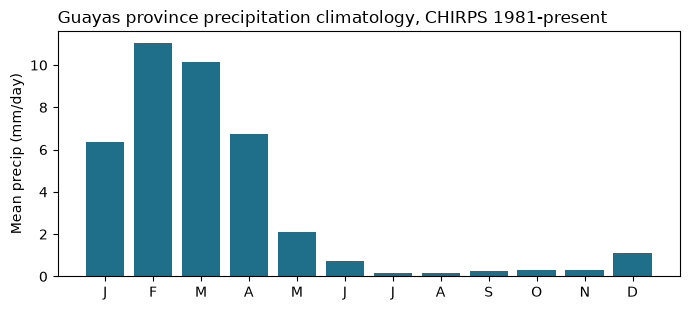

In [9]:
clim = s.groupby(s.index.month)["mean_mm"].mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(clim.index, clim.values, color="#1f6f8b")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylabel("Mean precip (mm/day)")
ax.set_title("Guayas province precipitation climatology, CHIRPS 1981-present", loc="left")
fig.tight_layout()

The pronounced Jan–Apr maximum and near-zero Jun–Nov is the expected coastal-Ecuador signature:
a single wet season driven by the seasonal southward migration of the ITCZ and warm coastal SSTs.
This is what makes the region so ENSO-sensitive, and it is why notebook 02's Dec–May window
appears repeatedly in this analysis.

## 5. The same reduction on a second product

Repeating the extraction on IMERG gives an independent estimate for the overlapping period. This
is not redundancy — it bounds the observational uncertainty in every result that follows.

In [10]:
imerg = xr.open_zarr(IMERG_ZARR)
mask_imerg = province_mask(imerg, guayas_geom)       # note: 0.1 deg grid -> far fewer cells
print("Guayas IMERG cells (0.1 deg):", int(mask_imerg.sum()))

imerg_path = DATA_DIR / "guayas_imerg_daily_series.csv"
if imerg_path.exists():
    imerg_series = pd.read_csv(imerg_path, parse_dates=["date"])
else:
    imerg_series = regional_series(imerg, "precipitation", mask_imerg)
    imerg_series.to_csv(imerg_path, index=False)

both = (guayas_series.set_index("date")[["mean_mm"]].rename(columns={"mean_mm": "chirps"})
        .join(imerg_series.set_index("date")[["mean_mm"]].rename(columns={"mean_mm": "imerg"}),
              how="inner"))
print("\noverlapping days:", len(both))
print(both.describe().round(2))
print("\nPearson r:", round(both.chirps.corr(both.imerg), 3))
print("IMERG / CHIRPS ratio of means:", round(both.imerg.mean() / both.chirps.mean(), 3))

Guayas IMERG cells (0.1 deg): 122

overlapping days: 9253
        chirps    imerg
count  9253.00  9253.00
mean      3.29     2.98
std      10.11     6.71
min       0.00     0.00
25%       0.00     0.09
50%       0.07     0.43
75%       1.37     2.26
max     167.08    79.38

Pearson r: 0.78
IMERG / CHIRPS ratio of means: 0.904


**Read this result carefully, because it propagates.** The two products correlate well in
*timing*, and the pooled means differ by only about 10%. That pooled number turns out to be
misleading -- the next cell stratifies the comparison by rain rate.

The consequence for the rest of the chain: IMERG-based and CHIRPS-based thresholds
(percentiles, exceedance counts) are **not interchangeable in absolute terms**. Notebook 04
computes each product's percentiles from its own distribution for exactly this reason, and any
figure showing both must say which product a threshold came from.

## What notebook 02 needs from here

`data/guayas_daily_series.csv` — one row per day, `date`, `mean_mm`, `max_mm`.

Everything downstream is driven by this file plus the ENSO index.

In [11]:
# Is the offset a constant scale factor, or does it depend on rain rate?
bands = [(0, 1, "dry (<1 mm)"), (1, 10, "1-10 mm"), (10, 30, "10-30 mm"),
         (30, 60, "30-60 mm"), (60, 1e9, ">60 mm")]
rows = []
for lo, hi, lab in bands:
    m = (both.chirps >= lo) & (both.chirps < hi)
    if m.sum() > 20:
        rows.append({"CHIRPS band": lab, "n_days": int(m.sum()),
                     "CHIRPS mean": round(both.chirps[m].mean(), 2),
                     "IMERG mean": round(both.imerg[m].mean(), 2),
                     "IMERG/CHIRPS": round(both.imerg[m].mean() / both.chirps[m].mean(), 3)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nall days pooled      :", round(both.imerg.mean() / both.chirps.mean(), 3))

CHIRPS band  n_days  CHIRPS mean  IMERG mean  IMERG/CHIRPS
dry (<1 mm)    6671         0.12        0.71         6.099
    1-10 mm    1733         3.69        4.34         1.176
   10-30 mm     601        17.53       14.15         0.807
   30-60 mm     197        40.81       25.31         0.620
     >60 mm      51        91.93       35.02         0.381

all days pooled      : 0.904


**The offset is not a constant, and the pooled ratio hides that.**

Pooled over all days the two products differ by only ~10%, which would suggest a mild, uniform
low bias in IMERG. Stratifying by rain rate shows something quite different: the ratio **crosses
one at around 10 mm/day**. IMERG places light rain where CHIRPS reports none (the dry-day ratio
is large because the CHIRPS denominator is near zero), tracks CHIRPS closely for modest rain,
and increasingly *under*-estimates as intensity rises — to roughly a third of CHIRPS on the
wettest days.

This is the single most consequential thing to carry forward from this notebook:

- **No scalar correction reconciles the two products.** A single multiplicative factor tuned on
  the mean would be wrong at both tails.
- **Percentiles and exceedance thresholds must be computed within each product**, never
  transferred between them. Notebook 04 does this, and the reason is this table.
- **The discrepancy is largest exactly where this analysis looks.** On the 137 heavy El Niño
  days selected in notebook 02, the ratio is near 0.5 — so IMERG- and CHIRPS-based extreme
  statistics will differ substantially in magnitude even though they agree on *which* days were
  extreme (r ≈ 0.78 above).

Which product is closer to truth here is not settled by this comparison. CHIRPS assimilates
station data, which is sparse in coastal Ecuador; IMERG's passive-microwave retrievals are known
to struggle over complex terrain and warm-rain regimes. Treat the spread as observational
uncertainty, and report which product any number came from.